# Tutorial - Module 1: Preprocessing

This notebook is a template workflow to collect data and prepare the main data to perform a baseline physical accessibility analysis to health facilities. It uses various tools developed by the World Bank's Geospatial Operations Support Team (GOST).

This notebook represents the first module of the tutorial on the physical accessibility to health facilities in a context of emergency. \
It focuses on the datasets and the functions to be used to perform the analysis and preprocess the datasets. \
We are going to apply the analysis to **Brazzaville, Congo**.

## Dataset Download Links
- [World Pop Raster](https://hub.worldpop.org/project/categories?id=3)
- [Global Human Settlement Layer](https://human-settlement.emergency.copernicus.eu/download.php?ds=pop)
- [Friction Surface](https://malariaatlas.org/geoserver/ows?service=CSW&version=2.0.1&request=DirectDownload&ResourceId=Explorer:2020_motorized_travel_time_to_healthcare)
- [Road network](https.://download.geofabrik.de/africa/congo-brazzaville.html)

## Setup

Import packages required for the analysis

In [290]:
# System
import sys
import os
from os.path import join, expanduser
from pathlib import Path
# Avoid warnings to pop up
import warnings
warnings.filterwarnings('ignore')

In [291]:
# Visualization tools
# import folium as flm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
from rasterio.plot import plotting_extent
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
import contextily as ctx
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

os.environ['CARTOPY_USER_BACKGROUNDS'] = '/home/jupyter-wb618081/Python/Backgrounds/'

In [292]:
# Processing 
import numpy as np
import geopandas as gpd
import pandas as pd
from gadm import GADMDownloader
import dask_geopandas as dask_gpd

# Raster
import rasterio as rio
from rasterio.features import shapes
from shapely.geometry import box
from rasterio.features import geometry_mask
from rasterstats import zonal_stats
from shapely.geometry import Polygon, box, Point
from shapely.geometry import mapping
import skimage.graph as graph
from scipy.signal import convolve2d

# Graph
import pickle
import networkx as nx
import osmnx as ox

# for facebook data
# from pyquadkey2 import quadkey

In [293]:
# Climate/Flood
# import xarray as xr

In [294]:
# Define your path to the Repositories

sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'gostrocks', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTNets_Raster', 'src'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOSTnets'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'GOST_Urban', 'src', 'GOST_Urban'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'health-equity-diagnostics', 'src', 'modules'))
sys.path.append(join(expanduser("/home/jupyter-wb618081"), 'Repos', 'INFRA_SAP'))

import GOSTnets as gn
from GOSTnets.load_osm import *
import GOSTRocks.rasterMisc as rMisc
from GOSTRocks.misc import get_utm
import GOSTNetsRaster.market_access as ma
import UrbanRaster as urban

from infrasap import aggregator
from infrasap import osm_extractor as osm   

from utils import download_osm_shapefiles

In [295]:
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Define below the local folder where you are located

In [296]:
scratch_dir = join(expanduser("/home/jupyter-wb618081"), 'Health-Access-Metrics', 'Tutorials')
data_dir = join(scratch_dir, 'tutorial_data')
out_path = join(scratch_dir, 'tutorial_output')

In [297]:
## Function for creating a path, if needed ##
def checkDir(out_path):
    if not os.path.exists(out_path):
        os.makedirs(out_path)

## Data Preparation

As a first thing, we need to define the Coordinate Systems we are going to use for our case study. \
In this case, apart from the standard WGS84 (EPSG code 4326, in degrees), we consider the UTM 32S (EPSG code 28232, in meters), which is "centered" on Congo. 

In [298]:
epsg = "EPSG:4326"
epsg_utm = "EPSG:28232"

### Import administrative units

In [299]:
country = 'Congo'
iso = 'COG'
downloader = GADMDownloader(version="4.0")
adm0 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=0)
adm1 = downloader.get_shape_data_by_country_name(country_name=country, ad_level=1)
assert isinstance(adm0, gpd.GeoDataFrame)

<Axes: >

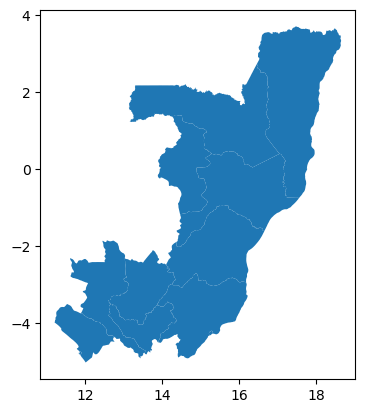

In [300]:
adm1.plot()

In [301]:
city = gpd.read_file((data_dir+"/brazaville.shp"))
city.to_crs(epsg)
city

,ID_0,COUNTRY,NAME_1,NL_NAME_1,ID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,COG,Republic of the Congo,Brazzaville,NaN,COG.2.1_1,Brazzaville,NaN,NaN,District,District,NaN,CG.BR.BR,"POLYGON ((15.32458 -4.28091, 15.31317 -4.27887..."


### Friction Surface (.tif)

An accessibility analysis, as any spatial analysis, can be accomplished by the utilization of a **RASTER**-based or a **VECTOR**-based approach. \
Within the first, we can use a Friction Surface, which represents the travel time by different means of transport for traversing a pixel. \
Within the second, we can use the road network retrieved by OpenStreeMap. 


Import a walking only and a motorized friction surface, for the years 2020 (from the Malaria Atlas Project) and an update for Africa for July 2024.

In [302]:
# Only the first time, clip the travel friction surface to the country of interest

# out_travel_surface = join(data_dir, f"travel_surface_walking_only_2024_{iso}.tif")
# if not os.path.isfile(out_travel_surface):
#     gfs_path = join(data_dir, 'T202407_walking_AFR.tif')
#     gfs_rio = rio.open(gfs_path)
#     rMisc.clipRaster(gfs_rio, adm0, out_travel_surface, crop=False)

The original friction surfaces extent has already been clipped to the country of interest, by using the GOSTrock **clipRaster** function of **rasterMisc**

In [303]:
?rMisc.clipRaster

Signature: rMisc.clipRaster(inR, inD, outFile, crop=True, buff=False)
Docstring:
Clip input raster
INPUT
[rasterio object] inR = rasterio.open(r"Q:/GLOBAL/POP&DEMO/GHS/BETA/FULL/MT/MT.vrt")
[geopandas object]inD = gpd.read_file(r"Q:\WORKINGPROJECTS\CityScan\Data\CityExtents\Conotou_AOI.shp")
[string]          outFile = r"Q:\WORKINGPROJECTS\CityScan\Data\CityExtents\Conotou_AOI\MappingData\GHSL.tif"
[Boolean] crop [default True] clip to exact extent of shape (True) or to bounding box (False)
File:      ~/Repos/gostrocks/src/GOSTRocks/rasterMisc.py
Type:      function

In [304]:
# Import the clipped friction surface
travel_surf_ft_24 = rio.open(join(data_dir, f"travel_surface_walking_only_2024_{iso}.tif")) #.read(1)
travel_surf_24 = rio.open(join(data_dir, f"travel_surface_motorized_2024_{iso}.tif")) #.read(1)

travel_surf_ft_20 = rio.open(join(data_dir, f"travel_surface_walking_only_2020_{iso}.tif")) #.read(1)
travel_surf_20 = rio.open(join(data_dir, f"travel_surface_motorized_2020_{iso}.tif")) #.read(1)

In [305]:
print("travel_surf_24:")
print(travel_surf_24.crs)
print(travel_surf_24.res)
print(" ")
print("travel_surf_20:")
print(travel_surf_20.crs)
print(travel_surf_20.res)

travel_surf_24:
ESRI:54034
(1000.0, 1000.0)
 
travel_surf_20:
EPSG:4326
(0.008333333333333333, 0.008333333333333333)


We can reproject and standardize the 2024 friction surface to the crs, extent and resolution of the 2020 friction surface. \
To do that, we can use the GOSTRock **rasterMisc** package, in particular the **standardizeInputRasters** function:

In [306]:
?rMisc.standardizeInputRasters

Signature:
rMisc.standardizeInputRasters(
    inR1,
    inR2,
    inR1_outFile='',
    resampling_type='nearest',
)
Docstring:
Standardize inR1 to inR2: changes crs, extent, and resolution.

Inputs:
inR1, inR2 [rasterio raster object]
[optional] inR1_outFile [string] - output file for creating inR1 standardized to inR2
[optional] data_type [string ['C','N']]

Returns:
[list] - [numpy array, raster metadata]
File:      ~/Repos/gostrocks/src/GOSTRocks/rasterMisc.py
Type:      function

In [307]:
rMisc.standardizeInputRasters(travel_surf_24, travel_surf_20, 
                              inR1_outFile=join(data_dir, f"travel_surface_motorized_2024_{iso}_std.tif"), resampling_type="nearest")

rMisc.standardizeInputRasters(travel_surf_ft_24, travel_surf_ft_20, 
                              inR1_outFile=join(data_dir, f"travel_surface_walking_only_2024_{iso}_std.tif"), resampling_type="nearest")

[array([[[0.012     , 0.012     , 0.012     , ..., 0.012     ,
          0.04152203, 0.0191303 ],
         [0.04045799, 0.03932085, 0.012     , ..., 0.012     ,
          0.012     , 0.012     ],
         [0.012     , 0.012     , 0.012     , ..., 0.01257193,
          0.012     , 0.012     ],
         ...,
         [0.        , 0.        , 0.        , ..., 0.0130035 ,
          0.012     , 0.012     ],
         [0.        , 0.        , 0.        , ..., 0.012     ,
          0.012     , 0.012     ],
         [0.        , 0.        , 0.        , ..., 0.012     ,
          0.012     , 0.01420765]]], dtype=float32),
 {'driver': 'GTiff',
  'dtype': 'float32',
  'nodata': 0.0,
  'width': 894,
  'height': 1049,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.008333333333333333, 0.0, 11.199999999999989,
         0.0, -0.008333333333333333, 3.7083333333333286)}]

In [308]:
travel_surf_ft_24 = rio.open(join(data_dir, f"travel_surface_walking_only_2024_{iso}_std.tif")) #.read(1)
travel_surf_24 = rio.open(join(data_dir, f"travel_surface_motorized_2024_{iso}_std.tif")) #.read(1)

In [309]:
print("travel_surf_24:")
print(travel_surf_24.crs)
print(travel_surf_24.res)

travel_surf_24:
EPSG:4326
(0.008333333333333333, 0.008333333333333333)


Let's take a quick look at the differences

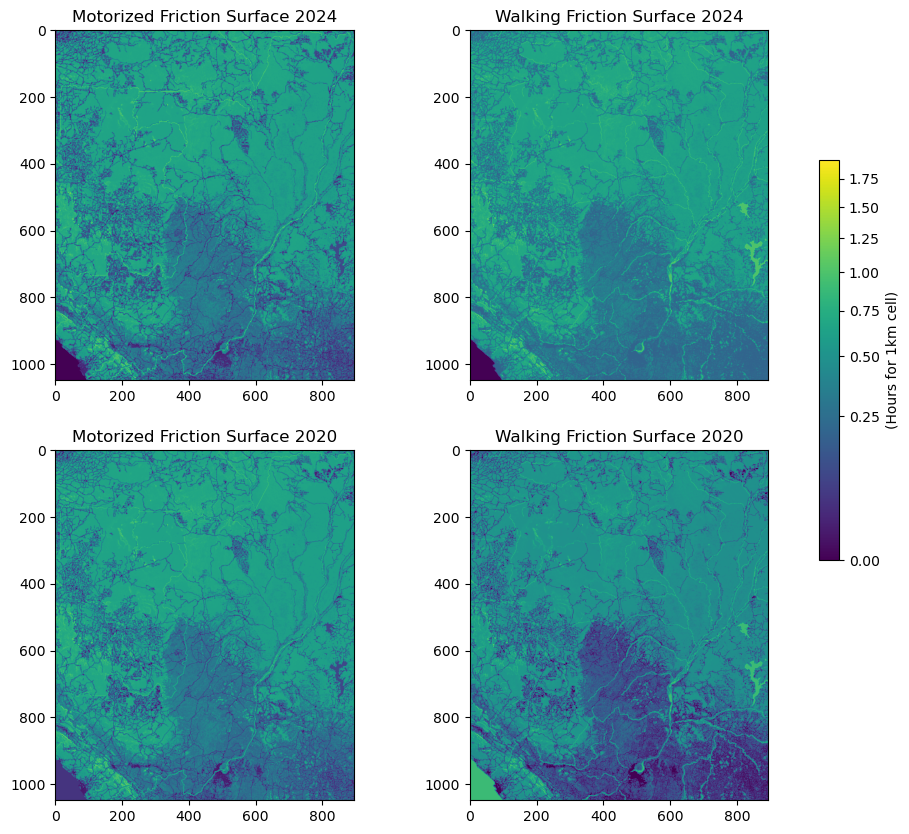

In [310]:
fig = plt.figure(figsize=(10, 10))  
grid = fig.add_gridspec(ncols=2, nrows=2, wspace=0.15)  # Create grid layout

# First panel
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title("Motorized Friction Surface 2024", fontsize=12, horizontalalignment='center')
im1 = ax1.imshow(travel_surf_24.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

# Second panel
ax2 = fig.add_subplot(grid[0, 1])
ax2.set_title("Walking Friction Surface 2024", fontsize=12, horizontalalignment='center')
im2 = ax2.imshow(travel_surf_ft_24.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

ax3 = fig.add_subplot(grid[1, 0])
ax3.set_title("Motorized Friction Surface 2020", fontsize=12, horizontalalignment='center')
im3 = ax3.imshow(travel_surf_20.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

ax4 = fig.add_subplot(grid[1, 1])
ax4.set_title("Walking Friction Surface 2020", fontsize=12, horizontalalignment='center')
im4 = ax4.imshow(travel_surf_ft_20.read(1)*1000/60, norm=colors.PowerNorm(gamma=0.5), cmap='viridis')

cax = fig.add_axes([0.92, 0.35, 0.02, 0.4])  # Position of the colorbar (left, bottom, width, height)
fig.colorbar(im1, cax=cax, orientation='vertical').set_label("(Hours for 1km cell)")

plt.show()

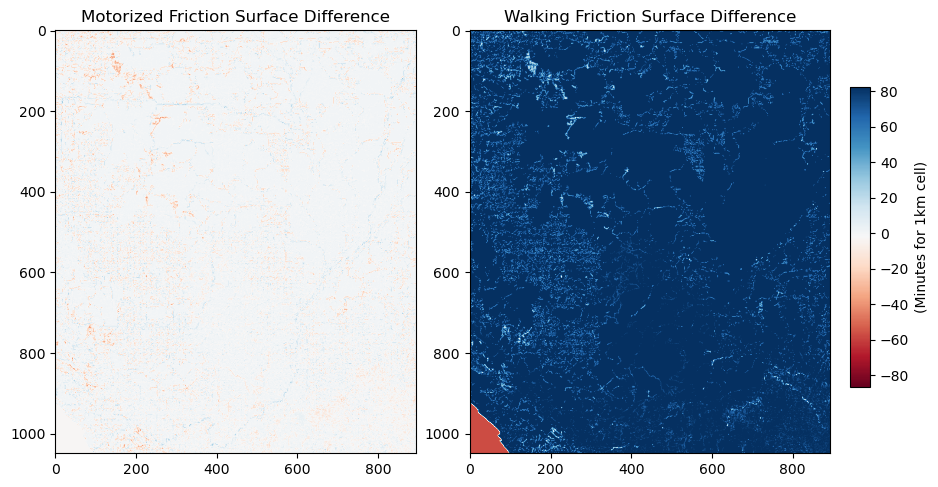

In [311]:
fig = plt.figure(figsize=(10, 10))  
grid = fig.add_gridspec(ncols=2, nrows=1, wspace=0.15)  # Create grid layout

# First panel
ax1 = fig.add_subplot(grid[0, 0])
ax1.set_title("Motorized Friction Surface Difference", fontsize=12, horizontalalignment='center')
im1 = ax1.imshow((travel_surf_24.read(1) - travel_surf_20.read(1))*1000, cmap='RdBu')

# Second panel
ax2 = fig.add_subplot(grid[0, 1])
ax2.set_title("Walking Friction Surface Difference", fontsize=12, horizontalalignment='center')
im2 = ax2.imshow((travel_surf_ft_24.read(1) - travel_surf_ft_20.read(1))*1000, cmap='RdBu')

cax = fig.add_axes([0.92, 0.35, 0.02, 0.3])  # Position of the colorbar (left, bottom, width, height)
fig.colorbar(im1, cax=cax, orientation='vertical').set_label("(Minutes for 1km cell)")

plt.show()

### Road Network (.shp)

Download from the link above the OpenStreetMap road network from Geofabrik

In [312]:
roads_osm = OSM_to_network(join(data_dir,"congo-brazzaville-latest.osm.pbf"))

GOSTNets creates a special 'OSM_to_network' object. This object gets initialized with both a copy of the OSM file itself and the roads extracted from the OSM file in a GeoPandas DataFrame. This DataFrame is a property of the object called 'roads_raw' and is the starting point for our network.

In [313]:
?roads_osm

Type:           OSM_to_network
String form:    <GOSTnets.load_osm.OSM_to_network object at 0x7c7462b823d0>
File:           ~/Repos/GOSTnets/GOSTnets/load_osm.py
Docstring:     
Object to load OSM PBF to networkX objects.

Object to load OSM PBF to networkX objects.     EXAMPLE:     G_loader = losm.OSM_to_network(bufferedOSM_pbf)     G_loader.generateRoadsGDF()     G = G.initialReadIn() 
snap origins and destinations     o_snapped = gn.pandana_snap(G, origins)     d_snapped = gn.pandana_snap(G, destinations)     
Init docstring: Generate a networkX object from a osm file

In [314]:
roads_gdf = roads_osm.roads_raw
roads_osm.roads_raw.head()

,osm_id,infra_type,one_way,bridge,geometry
0,4692113,primary,True,False,"LINESTRING (15.23126 -4.29689, 15.23134 -4.296..."
1,4692179,primary,True,False,"LINESTRING (15.25202 -4.28510, 15.25210 -4.285..."
2,4692181,primary,True,False,"LINESTRING (15.24010 -4.29174, 15.23988 -4.291..."
3,4692231,primary,True,False,"LINESTRING (15.28165 -4.27427, 15.28176 -4.274..."
4,4692245,primary,True,False,"LINESTRING (15.25944 -4.28030, 15.25946 -4.280..."


In [315]:
?roads_osm.roads_raw

Type:        GeoDataFrame
String form:
osm_id   infra_type  one_way  bridge  \
           0         4692113      primary     True   Fals <...>  -4.785...
           54721  LINESTRING (11.94277 -4.78254, 11.94306 -4.784...
           
           [54722 rows x 5 columns]
Length:      54722
File:        ~/.conda/envs/geo_wb_linux_parallel/lib/python3.8/site-packages/geopandas/geodataframe.py
Docstring:  
A GeoDataFrame object is a pandas.DataFrame that has a column
with geometry. In addition to the standard DataFrame constructor arguments,
GeoDataFrame also accepts the following keyword arguments:

Parameters
----------
crs : value (optional)
    Coordinate Reference System of the geometry objects. Can be anything accepted by
    :meth:`pyproj.CRS.from_user_input() <pyproj.crs.CRS.from_user_input>`,
    such as an authority string (eg "EPSG:4326") or a WKT string.
geometry : str or array (optional)
    If str, column to use as geometry. If array, will be set as 'geometry'
    column on Ge

We can show the different highway types and counts


In [316]:
roads_osm.roads_raw.infra_type.value_counts()

residential       35414
track              7667
unclassified       3599
path               2504
service            1696
tertiary           1608
trunk               746
secondary           655
primary             409
footway             297
primary_link         36
trunk_link           27
construction         21
tertiary_link        20
secondary_link        9
living_street         5
steps                 4
pedestrian            3
yes                   2
Name: infra_type, dtype: int64

We need to define a list of the types of roads from the above that we consider acceptable for our road network

In [317]:
accepted_road_types = ['residential', 'track','unclassified','path', 'service','tertiary','trunk','secondary','primary',
                       'footway','primary_link','trunk_link','secondary_link','tertiary_link']

We can therefore filter our roads using the **filterRoads** method

In [318]:
roads_osm.filterRoads(acceptedRoads = accepted_road_types)

In [319]:
roads_osm.roads_raw.infra_type.value_counts()

residential       35414
track              7667
unclassified       3599
path               2504
service            1696
tertiary           1608
trunk               746
secondary           655
primary             409
footway             297
primary_link         36
trunk_link           27
tertiary_link        20
secondary_link        9
Name: infra_type, dtype: int64

### Import the Health Facilities (destinations)

Health facilities are stored as Geopandas dataframe

In [320]:
hf = gpd.read_file((data_dir+"/hf_COG.shp"))

In [321]:
hf = hf[hf.geometry.intersects(city_shp)]

In [322]:
display('The following categories and numbers of Health Facilities are considered to perform the analysis: ')
display(hf["Facility t"].value_counts())

'The following categories and numbers of Health Facilities are considered to perform the analysis: '

Centre de Santé Intégré    22
l?Hôpital de Base           2
University Hospital         1
Name: Facility t, dtype: int64

### Import Population Datasets

Any accessibility analysis starts by considering a population dataset, a raster where each pixel represents the number of people living in that pixel area. \
Here we import some of the most used datasets, which differ in resolution (100m vs 1000m) and in their generation process: 


In [415]:
# wp_path = join(expanduser("R:/"), 'Data', 'GLOBAL/Population/WorldPop_PPP_2020/MOSAIC_ppp_prj_2020', f'ppp_prj_2020_{iso}.tif') # Download from link above

wp_path = join(data_dir, f'cog_ppp_2020_UNadj.tif') # Download from link above
pop_wp_uncost_100m = rio.open(wp_path)

wp_path = join(data_dir, f'cog_ppp_2020_UNadj_constrained.tif') # Download from link above
pop_wp_cost_100m = rio.open(wp_path)

wp_path = join(data_dir, f'cog_GHS_2020_1000.tif') # Download from link above
pop_ghs_1km = rio.open(wp_path)

wp_path = join(data_dir, f'cog_GHS_2020_100.tif') # Download from link above
pop_ghs_100m = rio.open(wp_path)

wp_path = join(data_dir, f'cog_GPW.tif') # Download from link above
pop_gpw_1km = rio.open(wp_path)

In [324]:
print(pop_ghs_1km.crs)
print(pop_ghs_1km.res)

ESRI:54009
(1000.0, 1000.0)


We can reproject and standardize the crs, extent and resolution of both the GHS population datasets to WGS84.

In [325]:
rMisc.standardizeInputRasters(pop_ghs_1km, pop_gpw_1km, 
                              inR1_outFile=join(data_dir, f"cog_GHS_2020_1000_std.tif"), resampling_type="nearest")

rMisc.standardizeInputRasters(pop_ghs_100m, pop_wp_cost_100m, 
                              inR1_outFile=join(data_dir, f"cog_GHS_2020_100_std.tif"), resampling_type="nearest")


[array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]),
 {'driver': 'GTiff',
  'dtype': 'float64',
  'nodata': -200.0,
  'width': 8939,
  'height': 10480,
  'count': 1,
  'crs': CRS.from_epsg(4326),
  'transform': Affine(0.0008333333300145432, 0.0, 11.200416637,
         0.0, -0.0008333333299618321, 3.702916853)}]

In [416]:
wp_path = join(data_dir, f'cog_GHS_2020_1000_std.tif')
pop_ghs_1km = rio.open(wp_path)

wp_path = join(data_dir, f'cog_GHS_2020_100_std.tif')
pop_ghs_100m = rio.open(wp_path)

In [417]:
print(pop_ghs_1km.crs)
print(pop_ghs_1km.res)

EPSG:4326
(0.00833333333333387, 0.00833333333333387)


In [422]:
# Convert geometries into the raster's CRS and create a mask
geometries = [mapping(geom) for geom in adm0.geometry]


# Create a geometry mask
mask = geometry_mask(geometries=geometries,
                     transform=pop_wp_uncost_100m.transform,
                     invert=True,  # invert=True means inside geometries will be True
                     out_shape=(pop_wp_uncost_100m.height, pop_wp_uncost_100m.width))  # Size of the raster

# Apply the mask to the raster data
pop_wp_uncost_100m_data = np.where(mask, pop_wp_uncost_100m.read(1), np.nan)  # Set values outside the mask to NaN


mask = geometry_mask(geometries=geometries,
                     transform=pop_wp_cost_100m.transform,
                     invert=True,  # invert=True means inside geometries will be True
                     out_shape=(pop_wp_cost_100m.height, pop_wp_cost_100m.width))  # Size of the raster

# Apply the mask to the raster data
pop_wp_cost_100m_data = np.where(mask, pop_wp_cost_100m.read(1), np.nan)  # Set values outside the mask to NaN


mask = geometry_mask(geometries=geometries,
                     transform=pop_ghs_1km.transform,
                     invert=True,  # invert=True means inside geometries will be True
                     out_shape=(pop_ghs_1km.height, pop_ghs_1km.width))  # Size of the raster

# Apply the mask to the raster data
pop_ghs_1km_data = np.where(mask, pop_ghs_1km.read(1), np.nan)  # Set values outside the mask to NaN


mask = geometry_mask(geometries=geometries,
                     transform=pop_ghs_100m.transform,
                     invert=True,  # invert=True means inside geometries will be True
                     out_shape=(pop_ghs_100m.height, pop_ghs_100m.width))  # Size of the raster

# Apply the mask to the raster data
pop_ghs_100m_data = np.where(mask, pop_ghs_100m.read(1), np.nan)  # Set values outside the mask to NaN


mask = geometry_mask(geometries=geometries,
                     transform=pop_gpw_1km.transform,
                     invert=True,  # invert=True means inside geometries will be True
                     out_shape=(pop_gpw_1km.height, pop_gpw_1km.width))  # Size of the raster

# Apply the mask to the raster data
pop_gpw_1km_data = np.where(mask, pop_gpw_1km.read(1), np.nan)  # Set values outside the mask to NaN

In [424]:
pop_wp_uncost_100m_data[pop_wp_uncost_100m_data==-99999] = 0
pop_wp_cost_100m_data[pop_wp_cost_100m_data==-99999] = 0
pop_ghs_100m_data[pop_ghs_100m_data==-99999] = 0
pop_ghs_1km_data[pop_ghs_1km_data==-99999] = 0
pop_gpw_1km_data[pop_gpw_1km_data==-99999] = 0

In [434]:
# Check descriptive statistics
print("World Pop Unconstrained, 100m res:")
print(f"Mean: {np.nanmean(pop_wp_uncost_100m_data)}")
print(f"Max: {np.nanmax(pop_wp_uncost_100m_data)}")
print(f"Min: {np.nanmin(pop_wp_uncost_100m_data)}")
print(f"Std: {np.nanstd(pop_wp_uncost_100m_data)}")
print("")
print("World Pop Constrained, 100m res:")
print(f"Mean: {np.nanmean(pop_wp_cost_100m_data)}")
print(f"Max: {np.nanmax(pop_wp_cost_100m_data)}")
print(f"Min: {np.nanmin(pop_wp_cost_100m_data)}")
print(f"Std: {np.nanstd(pop_wp_cost_100m_data)}")
print("")
print("Global Human Settlement, 100m res:")
print(f"Mean: {np.nanmean(pop_ghs_100m_data)}")
print(f"Max: {np.nanmax(pop_ghs_100m_data)}")
print(f"Min: {np.nanmin(pop_ghs_100m_data)}")
print(f"Std: {np.nanstd(pop_ghs_100m_data)}")
print("")
print("Global Human Settlement, 1km res:")
print(f"Mean: {np.nanmean(pop_ghs_1km_data)}")
print(f"Max: {np.nanmax(pop_ghs_1km_data)}")
print(f"Min: {np.nanmin(pop_ghs_1km_data)}")
print(f"Std: {np.nanstd(pop_ghs_1km_data)}")
print("")
print("Gridded Population of the World, 1km res:")
print(f"Mean: {np.nanmean(pop_gpw_1km_data)}")
print(f"Max: {np.nanmax(pop_gpw_1km_data)}")
print(f"Min: {np.nanmin(pop_gpw_1km_data)}")
print(f"Std: {np.nanstd(pop_gpw_1km_data)}")

World Pop Unconstrained, 100m res:
Mean: 0.13762299716472626
Max: 181.74049377441406
Min: 0.0
Std: 2.35477614402771

World Pop Constrained, 100m res:
Mean: 0.1378905326128006
Max: 384.94110107421875
Min: 0.0
Std: 4.2701215744018555

Global Human Settlement, 100m res:
Mean: 0.16620969043301465
Max: 2520.51708984375
Min: 0.0
Std: 7.705068611906313

Global Human Settlement, 1km res:
Mean: 17.136085067272155
Max: 63348.65024313331
Min: 0.0
Std: 654.8750818348602

Gridded Population of the World, 1km res:
Mean: 13.133438110351562
Max: 10745.431640625
Min: 0.0
Std: 195.91134643554688
